In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import LeaveOneOut, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.calibration import LabelEncoder
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTEN

In [2]:
input_data_filename = "./data/dataset_cleaned_397.csv"
raw_data = pd.read_csv(input_data_filename)

<strong>Clean Data</strong>: Remove non-features columns (protein name and symbol) and remove rows which have no data.

In [3]:
# DROP NON-FEATURE COLUMNS
data = raw_data.rename(columns={'REW (Convert to Numbers)': 'REW'})
data.drop(['ID (REMOVE)', 'SYMBOL', 'HGNC approved name'], axis=1, inplace=True)
data.replace('#', np.nan, inplace=True)

# REMOVE ROWS WITHOUT DATA
to_check = data.columns[5:] # remaining cols: 'Modification' , 'Protein complex', 'Target molecule', 'Target entity', 'Product'
data.dropna(how='all', subset=to_check, inplace=True)
data.replace(np.nan, '-', inplace=True)

# SEPARATE FEATURES AND LABELS
X_ = data.iloc[:, 1:].astype('category')
y_ = data.iloc[:, 0]

le = LabelEncoder()
y_categorical = le.fit_transform(y_)
class_labels = list(le.classes_)

<strong>Cross Validation</strong>: `ModelValidation` class for performing Leave-One-Out and k-fold cross validation.

In [10]:
class REWClassifier(ClassifierMixin, BaseEstimator):
    """Generic class for REW prediction using a given classifer."""

    categorical_cols = [
        'Pfam domains', 'HGNC gene family tag', 'HGNC gene family description', 
        'Function', 'Modification', 'Protein complex', 'Target molecule',
        'Target entity', 'Product'
    ]

    def __init__(
        self,
        name, 
        classifier,
        var_threshold=0.8*(1-0.8),
        num_features=9,
        random_state=42,
    ):
        self.name = name
        self.classifier = classifier
        self.var_threshold = var_threshold
        self.num_features = num_features
        self.random_state = random_state
        self.pipe = None
        self.best_estimator = None
        self.best_params = None
        self.classes_ = None

    def _build_pipeline(self):
        return Pipeline([
            # ("smote", SMOTEN(random_state=self.random_state)),
            ("one_hot", ColumnTransformer([
                (
                    "onehot", 
                    OneHotEncoder(handle_unknown="ignore"),
                    self.categorical_cols
                )
            ])),
            ("var_filter", VarianceThreshold(threshold=self.var_threshold)),
            ("ft_filter", SelectKBest(score_func=f_classif, k=self.num_features)),
            ("clf", self.classifier)
        ])

    def fit(self, X_train, y_train):
        self.pipe = self._build_pipeline()
        self.pipe.fit(X_train, y_train)
        self.classes_ = self.pipe.named_steps["clf"].classes_
        return self

    def predict(self, X_test):
        return self.pipe.predict(X_test)

    def predict_proba(self, X_test):
        return self.pipe.predict_proba(X_test)
    
    def tune(
        self,
        X,
        y, 
        param_grid,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1,
        use_best=False
    ):
        self.pipe = self._build_pipeline()
        grid = GridSearchCV(
            estimator=self.pipe,
            param_grid=param_grid,
            cv=cv,
            scoring=scoring,
            n_jobs=n_jobs,
            refit=True
        )
        grid.fit(X, y)

        self.best_params = grid.best_params_
        self.best_estimator = grid.best_estimator_

        if use_best:
            self.pipe = self.best_estimator
            self.classes_ = grid.best_estimator_.named_steps["clf"].classes_

        return self

In [7]:
param_grid = {
    "smote": [SMOTEN(random_state=42), "passthrough"]
}
nb_classifier = BernoulliNB()
nb_model = REWClassifier(name='Naive Bayes', classifier=nb_classifier)
nb_model.tune(X_, y_categorical, param_grid)

,name,'Naive Bayes'
,classifier,BernoulliNB()
,var_threshold,0.15999999999999998
,num_features,9
,random_state,42
,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [ ]:
nb_model.predict

{'smote': SMOTEN(random_state=42)}

<strong>Cross Validation</strong>: Cross validation methods for Leave-One-Out and Stratified-K-Fold validation.

In [11]:
def loocv(model, X, y):
    """Perform Leave-One-Out Cross Validation on the dataset."""

    y_proba = cross_val_predict(model, X, y, cv=LeaveOneOut(), method="predict_proba")
    y_preds = np.argmax(y_proba, axis=1)
    
    acc = accuracy_score(y, y_preds)
    f1 = f1_score(y, y_preds, average='macro')
    auc = roc_auc_score(y, y_proba, multi_class='ovr')
    cm = confusion_matrix(y, y_preds)
    return acc, f1, auc, cm

def kfoldcv(model, X, y, k=5):
    """Perform k-fold cross validation on the dataset."""

    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    accs = []
    f1s = []
    aucs = []
    cms = []

    for split, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)

        y_preds = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        accs.append(accuracy_score(y_test, y_preds))
        f1s.append(f1_score(y_test, y_preds, average="macro"))
        aucs.append(roc_auc_score(y_test, y_proba, multi_class="ovr"))
        cms.append(confusion_matrix(y_test, y_preds))

    acc = np.mean(accs)
    f1 = np.mean(f1s)
    auc = np.mean(aucs)
    cm = np.sum(cms, axis=0)
    return acc, f1, auc, cm 

In [12]:
def get_confusion_matrix(confusion_matrix, model_name, class_labels, save_to=None):
    """Generate a heatmap visualization of a confusion matrix."""

    sns.set_theme(style="white", font_scale=1.2)
    plt.figure(figsize=(4, 4))
    ax = sns.heatmap(confusion_matrix, 
                    annot=True,
                    square=True, 
                    xticklabels=class_labels, 
                    yticklabels=class_labels, 
                    cmap='RdPu', 
                    fmt="d",
                    cbar_kws={"shrink": 0.85})
    ax.xaxis.tick_top()
    ax.yaxis.tick_left()
    ax.set_xticklabels(class_labels, fontsize=14)
    ax.set_yticklabels(class_labels, fontsize=14)
    plt.xlabel(model_name, fontsize=14, labelpad=11)
    plt.yticks(rotation=0)
    plt.xticks(rotation=0)
    if save_to:
        plt.savefig(save_to, 
                    format="png", 
                    bbox_inches='tight', 
                    dpi=600)
    return plt

<strong>Models</strong>: Define models for comparison.

In [6]:
# Naive Bayes
nb_classifier = BernoulliNB()
nb_model = REWClassifier(name='Naive Bayes', classifier=nb_classifier)

# Multi-Layer Perceptron
mlp_classifier = MLPClassifier(
    hidden_layer_sizes = (100, 100),
    activation='relu', 
                                    solver='lbfgs',
                                    random_state=42,
                                    max_iter=5000)
mlp_model = REWClassifier(name='Multi-Layer Perceptron', classifier=mlp_classifier)

# Deep Neural Network
dnn_classifier = MLPClassifier(hidden_layer_sizes = (100, 100, 100),
                                    activation='relu', 
                                    solver='lbfgs',
                                    random_state=42,
                                    max_iter=5000)
dnn_model = REWClassifier(name='Deep Neural Network', classifier=dnn_classifier)


# K-Nearest Neighbor
knn_classifier = KNeighborsClassifier(n_neighbors=10,
                                    metric='l1')
knn_model = REWClassifier(name='K-Nearest Neighbor', classifier=knn_classifier)
        

# Decision Tree
dt_classifier = DecisionTreeClassifier(criterion='gini',
                                    max_depth=6)
dt_model = REWClassifier(name='Decision Tree', classifier=dt_classifier)


# Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100,
                                    criterion='gini',
                                    bootstrap=True,
                                    max_depth=6)
rf_model = REWClassifier(name='Random Forest', classifier=rf_classifier)


# Support Vector Machine
svc_classifier = SVC(probability=True)
svc_model = REWClassifier(name='Support Vector Machine', classifier=svc_classifier)


# Logistic Regression
lr_classifier = LogisticRegression(l1_ratio=0)
lr_model = REWClassifier(name='Logistic Regression', classifier=lr_classifier)


models = [nb_model, mlp_model, dnn_model, knn_model, dt_model, rf_model, svc_model, lr_model]

Evaluating Naive Bayes model...
Evaluating Multi-Layer Perceptron model...
Evaluating Deep Neural Network model...
Evaluating K-Nearest Neighbor model...


c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Evaluating Decision Tree model...
Evaluating Random Forest model...
Evaluating Support Vector Machine model...
Evaluating Logistic Regression model...


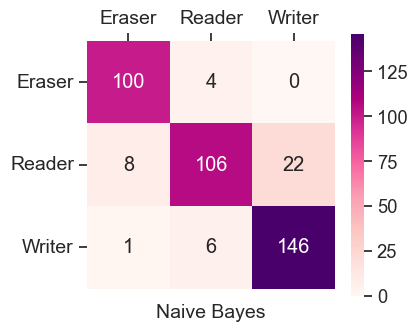

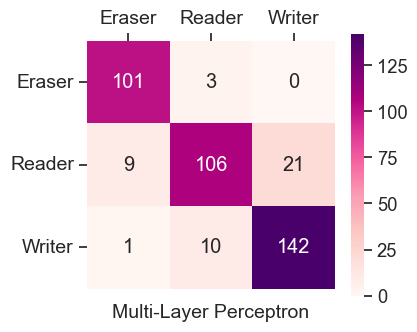

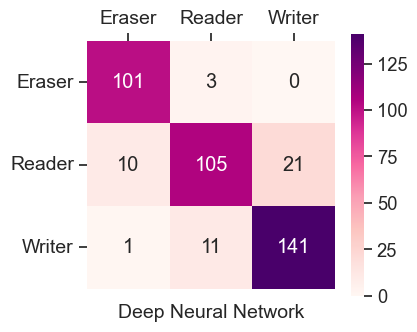

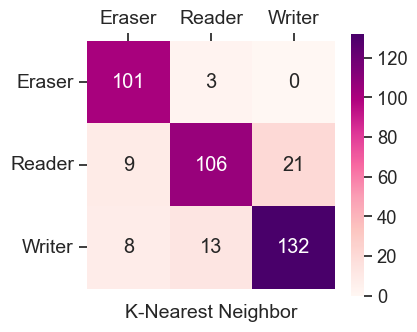

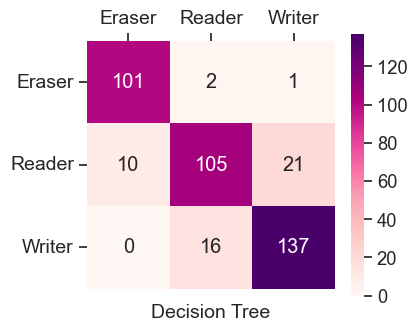

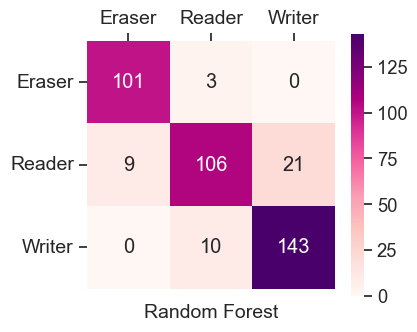

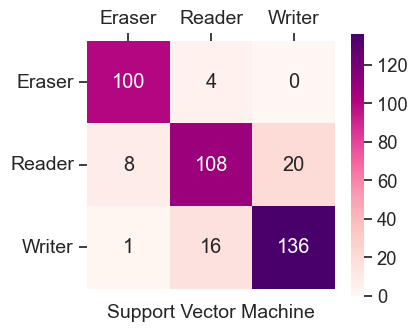

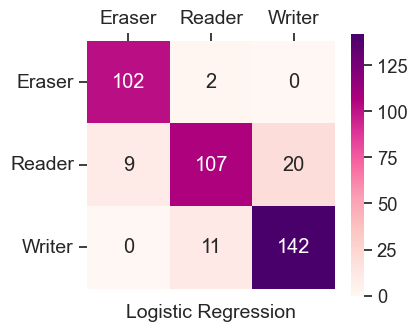

In [13]:
accuracies = {}
f1_scores = {}
auc_rocs = {}
confusion_matrices = []
for model in models:
    print(f'Evaluating {model.name} model...')
    results = None

    results = kfoldcv(model, X_, y_categorical)

    accuracies[model.name] = results[0]
    f1_scores[model.name] = results[1]
    auc_rocs[model.name] = results[2]
    confusion_matrices.append(results[3])
    get_confusion_matrix(confusion_matrix=results[3], 
                         model_name=model.name,
                                class_labels=class_labels, 
                                save_to=f'{model.name}_cm.png')
    
    import json
    # write numerical metrics to a file
    with open('model_accuracies.json', 'w') as f:
        json.dump(accuracies, f)
    with open('model_f1_scores.json', 'w') as f:
        json.dump(f1_scores, f)
    with open('model_aucs.json', 'w') as f:
        json.dump(auc_rocs, f)